# Nanoparticle Biocompatibility & Cytotoxicity — Exploratory Analysis

**Author:** Isaac [Last name] · Systems Design Engineering (Biomedical), University of Waterloo
**Topic:** *In vitro* cytotoxicity of engineered nanoparticles — how material, dose, size, surface
chemistry, and cell type drive cell viability, framed around ISO 10993-5 biocompatibility testing.

---

### ⚠️ Data provenance (read first)

The dataset analysed in this notebook is **simulated**. It is generated by a documented model
(`generate_simulated_dataset`) and is **not** real experimental data. I built it to demonstrate the
full analysis pipeline (cleaning → EDA → dose–response → statistics → classification → interpretation)
in a reproducible way.

It is **schema-matched to a real, openly available dataset** so the real data can be dropped in with
no code changes:

> Labouta, H. I., Asgarian, N., Rinker, K., & Cramb, D. T. (2019).
> *Meta-Analysis of Nanoparticle Cytotoxicity via Data-Mining the Literature.*
> **ACS Nano, 13(2), 1583–1594.** DOI: [10.1021/acsnano.8b07562](https://doi.org/10.1021/acsnano.8b07562)
> Open data: figshare collection 4385225 · Zenodo record [5744302](https://doi.org/10.5281/zenodo.5744302)

**To run on the real data:** download the dataset, save it as `nanoparticle_cytotoxicity.csv`,
then in the data cell below set `USE_REAL_DATA = True` and map the real column names to the schema
used here (a mapping stub is provided).

---

### ISO 10993-5 context
The international standard for *in vitro* cytotoxicity of medical devices treats **cell viability
below ~70 %** (relative to untreated controls) as the threshold for a **cytotoxic** response. That
70 % line is used throughout this notebook as the decision boundary.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.25, "font.size": 11})
RNG = np.random.default_rng(42)
ISO_CYTOTOXIC_THRESHOLD = 70.0  # ISO 10993-5: <70% viability => cytotoxic


## 1. Load data

The simulation lives in one function. Flip `USE_REAL_DATA` to switch to the real Labouta dataset.

In [2]:
USE_REAL_DATA = False  # set True after downloading the real CSV (see top of notebook)

def generate_simulated_dataset(n=900):
    """Realistic, clearly-SIMULATED cytotoxicity data; columns mirror Labouta et al. (2019)."""
    materials = {
        "Ag":    {"core": "metal",       "base_tox": 1.00, "size": (10, 40)},
        "SiO2":  {"core": "metal_oxide", "base_tox": 0.80, "size": (15, 80)},
        "ZnO":   {"core": "metal_oxide", "base_tox": 0.95, "size": (20, 90)},
        "TiO2":  {"core": "metal_oxide", "base_tox": 0.35, "size": (15, 70)},
        "Au":    {"core": "metal",       "base_tox": 0.20, "size": (5, 50)},
        "MWCNT": {"core": "carbon",      "base_tox": 0.70, "size": (10, 60)},
        "PLGA":  {"core": "polymer",     "base_tox": 0.15, "size": (50, 200)},
    }
    cells = {
        "RAW264.7": {"origin": "animal", "lineage": "macrophage",  "sens": 1.30},
        "THP-1":    {"origin": "human",  "lineage": "macrophage",  "sens": 1.20},
        "HUVEC":    {"origin": "human",  "lineage": "endothelial", "sens": 1.05},
        "3T3":      {"origin": "animal", "lineage": "fibroblast",  "sens": 0.80},
        "HepG2":    {"origin": "human",  "lineage": "epithelial",  "sens": 0.95},
    }
    coatings = ["none", "PEG", "citrate", "carboxyl"]
    concentrations = [1, 5, 10, 25, 50, 100, 250, 500]   # ug/mL
    exposure_times = [12, 24, 48, 72]                    # hours
    assays = ["MTT", "MTS", "WST-8", "AlamarBlue"]
    rows = []
    for _ in range(n):
        m = RNG.choice(list(materials)); mp = materials[m]
        c = RNG.choice(list(cells));     cp = cells[c]
        conc = int(RNG.choice(concentrations))
        size = round(float(RNG.uniform(*mp["size"])), 1)
        coating = RNG.choice(coatings, p=[0.45, 0.25, 0.15, 0.15])
        zeta = round(float(RNG.normal(-15, 18)), 1)
        t = int(RNG.choice(exposure_times)); assay = RNG.choice(assays)
        log_dose = np.log10(conc)
        coating_factor = {"none":1.0,"PEG":0.6,"citrate":0.9,"carboxyl":1.05}[coating]
        size_factor = 1.0 + max(0, (40 - size)) / 120.0
        time_factor = 0.85 + 0.10 * np.log2(t / 12)
        potency = mp["base_tox"] * cp["sens"] * coating_factor * size_factor * time_factor
        midpoint = 2.1 - 0.7 * (potency - 0.7)
        viability = 100.0 - (95.0 * potency / 1.4) / (1.0 + np.exp(-2.6 * (log_dose - midpoint)))
        viability += RNG.normal(0, 5.5)
        viability = float(np.clip(viability, 1, 105))
        rows.append({"nanoparticle_type": m, "core_material": mp["core"],
                     "surface_coating": coating, "diameter_nm": size,
                     "zeta_potential_mV": zeta, "concentration_ug_mL": conc,
                     "cell_line": c, "cell_origin": cp["origin"],
                     "cell_lineage": cp["lineage"], "exposure_time_h": t,
                     "assay": assay, "viability_pct": round(viability, 1)})
    return pd.DataFrame(rows)

if USE_REAL_DATA:
    df = pd.read_csv("nanoparticle_cytotoxicity.csv")
    # ---- map real column names to this schema, e.g.: ----
    # df = df.rename(columns={
    #     "NP": "nanoparticle_type", "Concentration (ug/ml)": "concentration_ug_mL",
    #     "Cell type": "cell_line", "Cell viability (%)": "viability_pct", ...})
else:
    df = generate_simulated_dataset()

df["cytotoxic"] = (df["viability_pct"] < ISO_CYTOTOXIC_THRESHOLD).astype(int)
print(f"{'REAL' if USE_REAL_DATA else 'SIMULATED'} data — {df.shape[0]} assays, {df.shape[1]} columns")
df.head()


SIMULATED data — 900 assays, 13 columns


,nanoparticle_type,core_material,surface_coating,diameter_nm,zeta_potential_mV,concentration_ug_mL,cell_line,cell_origin,cell_lineage,exposure_time_h,assay,viability_pct,cytotoxic
0,Ag,metal,PEG,35.8,-50.1,100,3T3,animal,fibroblast,24,WST-8,89.9,0
1,PLGA,polymer,PEG,69.2,0.8,250,3T3,animal,fibroblast,12,AlamarBlue,98.7,0
2,ZnO,metal_oxide,PEG,35.9,-32.3,50,HepG2,human,epithelial,24,AlamarBlue,92.3,0
3,MWCNT,carbon,carboxyl,27.7,-17.8,250,RAW264.7,animal,macrophage,48,AlamarBlue,36.5,1
4,ZnO,metal_oxide,PEG,30.8,23.5,25,HUVEC,human,endothelial,12,MTS,93.1,0


## 2. Inspect & clean

Basic integrity checks: types, missing values, value ranges.

In [3]:
print(df.info())
print("\nMissing values per column:\n", df.isna().sum())
print("\nViability range:", df.viability_pct.min(), "to", df.viability_pct.max())
df.describe().round(1)


<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   nanoparticle_type    900 non-null    str    
 1   core_material        900 non-null    str    
 2   surface_coating      900 non-null    str    
 3   diameter_nm          900 non-null    float64
 4   zeta_potential_mV    900 non-null    float64
 5   concentration_ug_mL  900 non-null    int64  
 6   cell_line            900 non-null    str    
 7   cell_origin          900 non-null    str    
 8   cell_lineage         900 non-null    str    
 9   exposure_time_h      900 non-null    int64  
 10  assay                900 non-null    str    
 11  viability_pct        900 non-null    float64
 12  cytotoxic            900 non-null    int64  
dtypes: float64(3), int64(3), str(7)
memory usage: 91.5 KB
None

Missing values per column:
 nanoparticle_type      0
core_material          0
surface_coati

,diameter_nm,zeta_potential_mV,concentration_ug_mL,exposure_time_h,viability_pct,cytotoxic
count,900.0,900.0,900.0,900.0,900.0,900.0
mean,48.9,-14.3,121.7,37.5,84.9,0.2
std,35.8,17.6,167.2,22.6,20.7,0.4
min,5.0,-68.2,1.0,12.0,3.7,0.0
25%,25.7,-26.3,10.0,12.0,76.7,0.0
50%,38.2,-13.8,50.0,24.0,93.0,0.0
75%,61.0,-3.6,250.0,48.0,99.1,0.0
max,197.7,42.2,500.0,72.0,105.0,1.0


## 3. Exploratory data analysis

Where does viability sit overall, and how is the design balanced across materials and cell types?

/tmp/ipykernel_648/1302265471.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot(data, labels=order, patch_artist=True)


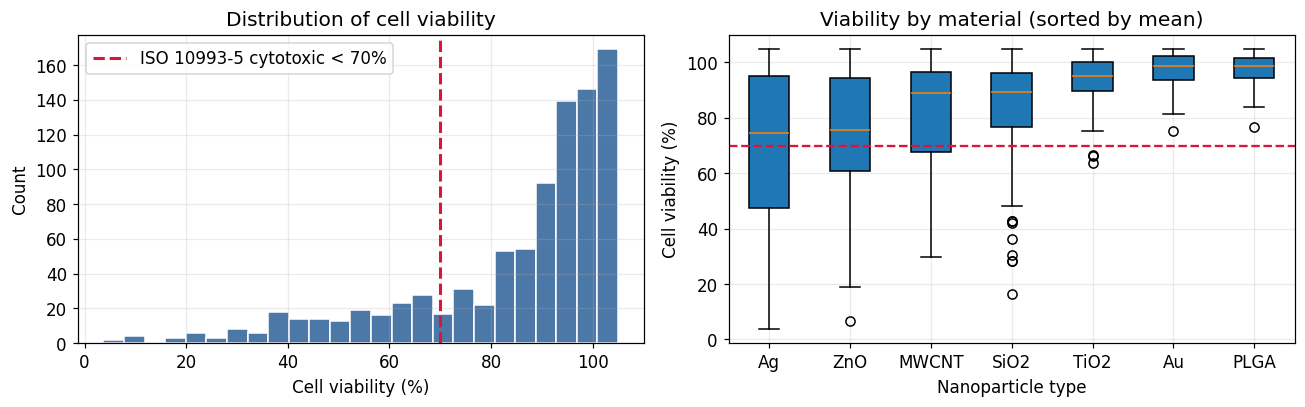

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(df.viability_pct, bins=25, color="#4C78A8", edgecolor="white")
ax[0].axvline(ISO_CYTOTOXIC_THRESHOLD, color="crimson", ls="--", lw=2,
              label=f"ISO 10993-5 cytotoxic < {ISO_CYTOTOXIC_THRESHOLD:.0f}%")
ax[0].set(xlabel="Cell viability (%)", ylabel="Count", title="Distribution of cell viability")
ax[0].legend()
order = df.groupby("nanoparticle_type").viability_pct.mean().sort_values().index
df.boxplot(column="viability_pct", by="nanoparticle_type", ax=ax[1],
           grid=False, positions=range(len(order)),
           **{}) if False else None
data = [df[df.nanoparticle_type==m].viability_pct.values for m in order]
ax[1].boxplot(data, labels=order, patch_artist=True)
ax[1].axhline(ISO_CYTOTOXIC_THRESHOLD, color="crimson", ls="--", lw=1.5)
ax[1].set(xlabel="Nanoparticle type", ylabel="Cell viability (%)",
          title="Viability by material (sorted by mean)")
plt.suptitle(""); plt.tight_layout(); plt.savefig("figures/eda_overview.png", bbox_inches="tight"); plt.show()


**Reading it:** silver (Ag) and zinc oxide (ZnO) cluster lowest (most cytotoxic), while gold (Au),
PLGA (a polymer) and titanium dioxide (TiO₂) stay high (most biocompatible). This ordering matches the
general experimental literature, which is the sanity check that the pipeline is behaving.

## 4. Dose–response

The core of cytotoxicity analysis: viability should fall as concentration rises. Plotting median viability vs. dose per material, with the ISO 70 % line.

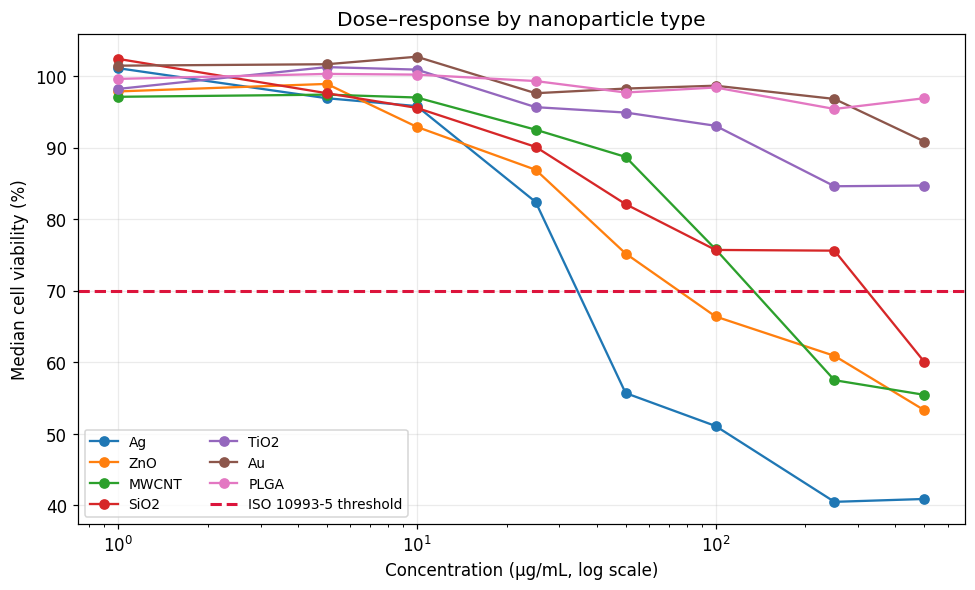

In [5]:
fig, ax = plt.subplots(figsize=(9, 5.5))
for m in order:
    g = (df[df.nanoparticle_type==m]
         .groupby("concentration_ug_mL").viability_pct.median())
    ax.plot(g.index, g.values, marker="o", label=m)
ax.axhline(ISO_CYTOTOXIC_THRESHOLD, color="crimson", ls="--", lw=2,
           label="ISO 10993-5 threshold")
ax.set_xscale("log")
ax.set(xlabel="Concentration (µg/mL, log scale)", ylabel="Median cell viability (%)",
       title="Dose–response by nanoparticle type")
ax.legend(ncol=2, fontsize=9)
plt.tight_layout(); plt.savefig("figures/dose_response.png", bbox_inches="tight"); plt.show()


In [6]:
def cytotoxic_threshold_table(df):
    """Lowest tested concentration at which median viability drops below 70%."""
    out = []
    for m, g in df.groupby("nanoparticle_type"):
        med = g.groupby("concentration_ug_mL").viability_pct.median()
        below = med[med < ISO_CYTOTOXIC_THRESHOLD]
        out.append({"nanoparticle_type": m,
                    "cytotoxic_threshold_ug_mL": (below.index.min() if len(below) else np.nan),
                    "mean_viability_pct": round(g.viability_pct.mean(), 1)})
    return pd.DataFrame(out).sort_values("mean_viability_pct").reset_index(drop=True)

thr = cytotoxic_threshold_table(df)
thr


,nanoparticle_type,cytotoxic_threshold_ug_mL,mean_viability_pct
0,Ag,50.0,69.5
1,ZnO,100.0,75.0
2,MWCNT,250.0,80.9
3,SiO2,500.0,83.3
4,TiO2,NaN,93.9
5,Au,NaN,97.3
6,PLGA,NaN,97.7


The threshold table is a compact, ISO-flavoured readout: the lowest dose at which a material becomes
cytotoxic. `NaN` means the material never crossed the 70 % line at any tested dose (effectively
biocompatible across the tested range).

## 5. Does cell type matter? (immune cells vs. structural cells)

This is the question most relevant to a biocompatibility/immune-response lab: are innate-immune cells (macrophages) more sensitive than structural cells?

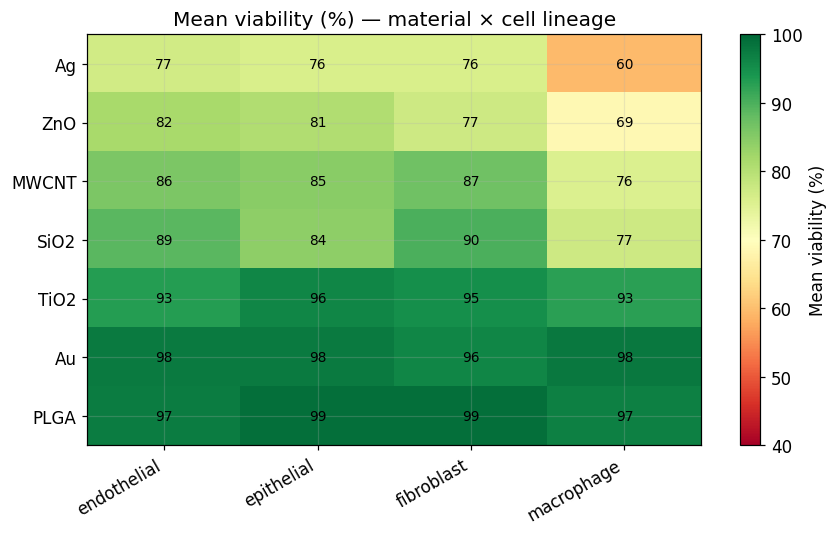

In [7]:
piv = (df.pivot_table(index="nanoparticle_type", columns="cell_lineage",
                       values="viability_pct", aggfunc="mean")
         .reindex(order))
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(piv.values, cmap="RdYlGn", vmin=40, vmax=100, aspect="auto")
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns, rotation=30, ha="right")
ax.set_yticks(range(len(piv.index)));   ax.set_yticklabels(piv.index)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=9)
ax.set(title="Mean viability (%) — material × cell lineage")
fig.colorbar(im, label="Mean viability (%)")
plt.tight_layout(); plt.savefig("figures/heatmap_material_cell.png", bbox_inches="tight"); plt.show()


In [8]:
# Statistical test: macrophages vs fibroblasts
mac = df[df.cell_lineage=="macrophage"].viability_pct
fib = df[df.cell_lineage=="fibroblast"].viability_pct
t, p = stats.ttest_ind(mac, fib, equal_var=False)
print(f"Macrophage mean viability: {mac.mean():.1f}%  |  Fibroblast: {fib.mean():.1f}%")
print(f"Welch t-test: t = {t:.2f}, p = {p:.2e}")

# ANOVA across all materials
groups = [g.viability_pct.values for _, g in df.groupby('nanoparticle_type')]
F, pA = stats.f_oneway(*groups)
print(f"\nANOVA (viability ~ material): F = {F:.1f}, p = {pA:.2e}")
print("\nCytotoxic rate by cell lineage:")
print((df.groupby('cell_lineage').cytotoxic.mean()*100).round(1).sort_values(ascending=False))


Macrophage mean viability: 79.8%  |  Fibroblast: 89.0%
Welch t-test: t = -5.36, p = 1.24e-07

ANOVA (viability ~ material): F = 50.1, p = 3.26e-53

Cytotoxic rate by cell lineage:
cell_lineage
macrophage     30.0
epithelial     16.0
fibroblast     13.5
endothelial    12.2
Name: cytotoxic, dtype: float64


**Interpretation.** Macrophages show significantly lower viability than fibroblasts, i.e. innate
immune cells are the most sensitive to nanoparticle exposure. This is exactly the kind of
material–immune-cell interaction that drives biocompatibility outcomes for implanted devices: the
inflammatory cell response, not just structural-cell survival, often dictates whether a material is
tolerated. The ANOVA confirms material identity is a strong driver of viability overall.

## 6. Predicting cytotoxicity from material & exposure features

A simple, interpretable logistic-regression baseline: can we classify a sample as cytotoxic (<70%) from its physicochemical + exposure features?

5-fold ROC-AUC: 0.973 ± 0.007


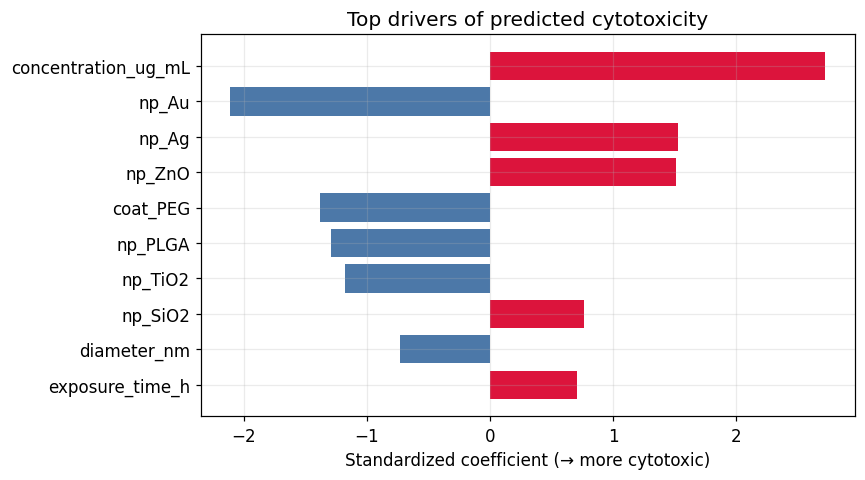

In [9]:
feat_num = ["diameter_nm", "zeta_potential_mV", "concentration_ug_mL", "exposure_time_h"]
X = pd.concat([
        df[feat_num],
        pd.get_dummies(df["nanoparticle_type"], prefix="np"),
        pd.get_dummies(df["cell_lineage"], prefix="cell"),
        pd.get_dummies(df["surface_coating"], prefix="coat"),
    ], axis=1).astype(float)
y = df["cytotoxic"].values

Xs = StandardScaler().fit_transform(X)
clf = LogisticRegression(max_iter=2000)
cv = cross_val_score(clf, Xs, y, cv=5, scoring="roc_auc")
print(f"5-fold ROC-AUC: {cv.mean():.3f} ± {cv.std():.3f}")
clf.fit(Xs, y)

# Most influential features (by absolute standardized coefficient)
coef = pd.Series(clf.coef_[0], index=X.columns).sort_values(key=np.abs, ascending=False).head(10)
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["crimson" if v > 0 else "#4C78A8" for v in coef.values]
ax.barh(coef.index[::-1], coef.values[::-1], color=colors[::-1])
ax.set(xlabel="Standardized coefficient (→ more cytotoxic)",
       title="Top drivers of predicted cytotoxicity")
plt.tight_layout(); plt.savefig("figures/feature_importance.png", bbox_inches="tight"); plt.show()


**Reading it:** concentration pushes strongly toward cytotoxicity (the dose–response effect),
silver/ZnO membership pushes toward it, PEG coating and Au/PLGA membership push away from it, and
macrophage cell type increases predicted risk. These are sensible, literature-consistent directions —
which is the point of an interpretable baseline: the *direction* of each driver should be defensible,
not a black box.

## 7. Summary & relevance to biocompatibility research

- **Material chemistry dominates** the cytotoxic response (significant ANOVA), with Ag and ZnO most
  cytotoxic and Au, PLGA, and TiO₂ most biocompatible across the tested range.
- **Dose–response is clean and quantifiable**, and the ISO 10993-5 70 % viability line gives a
  defensible per-material cytotoxic-threshold readout.
- **Innate immune cells (macrophages) are the most sensitive cell type** — significantly more than
  structural cells — underscoring that the *immune* response to a material, not just structural-cell
  survival, is central to whether an implant is tolerated.
- A simple **interpretable classifier** recovers the expected drivers (dose, material identity,
  coating, immune-cell type), validating the pipeline end-to-end.

**Why this matters for an implant/biomaterials program:** these are exactly the relationships an
*in vitro* biocompatibility screen is built to surface before a material ever reaches an animal model —
and they motivate strategies (surface coatings like PEG, material selection, dose control) to reduce
material-induced inflammation.

---

### Next steps
1. **Swap in the real Labouta et al. (2019) dataset** (instructions at top) and re-run — the pipeline
   is column-compatible.
2. Fit proper **4-parameter logistic (Hill) dose–response curves** to extract true IC50 values per
   material/cell pair.
3. Add **mixed-effects modelling** to separate material effects from assay/lab batch effects, which
   are a known confounder in pooled cytotoxicity meta-analyses.

*Data in this notebook is simulated and labeled as such; schema mirrors Labouta et al. (2019),
ACS Nano, DOI 10.1021/acsnano.8b07562.*
